In [1]:
!pip install opencv-python

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

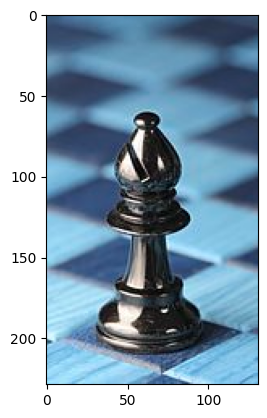

In [3]:
img = cv2.imread('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Bishop/00000000.JPG')
plt.imshow(img)

In [4]:
img.shape

(229, 131, 3)

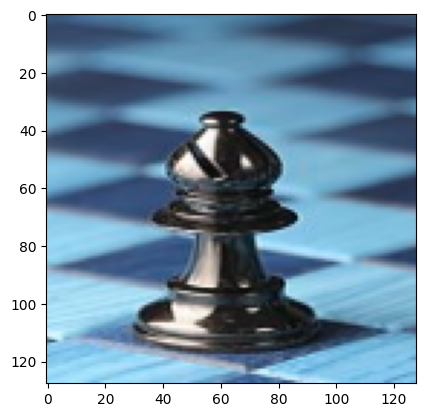

In [5]:
img = cv2.resize(img,(128,128),interpolation=cv2.INTER_AREA)
plt.imshow(img)

In [6]:
img.max()

np.uint8(255)

In [7]:
img.min()

np.uint8(0)

In [8]:
img = (img - img.min())/(img.max() - img.min())

In [9]:
img.max()

np.float64(1.0)

In [10]:
img.min()

np.float64(0.0)

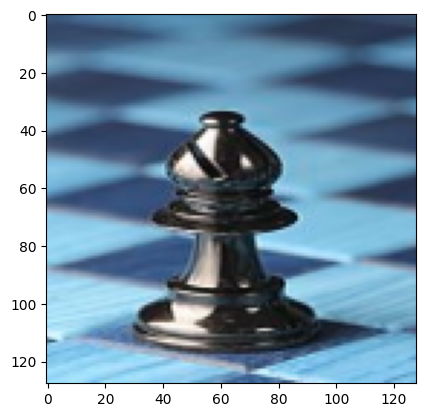

In [11]:
plt.imshow(img)

In [12]:
bishop = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Bishop')
king = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/King')
knight = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Knight')
pawn = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Pawn')
queen = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Queen')
rook = os.listdir('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Rook')

In [16]:
X = []

In [17]:
Y = []

In [18]:
# Bishop
for f in bishop[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Bishop', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(0)

# King
for f in king[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/King', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(1)

# Knight
for f in knight[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Knight', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(2)

# Pawn
for f in pawn[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Pawn', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(3)

# Queen
for f in queen[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Queen', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(4)

# Rook
for f in rook[:50]:
    img = cv2.imread(os.path.join('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Rook', f))
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_AREA)
    img = (img - img.min()) / (img.max() - img.min())
    X.append(img)
    Y.append(5)

In [19]:
X = np.array(X)
Y = np.array(Y)

In [20]:
X.shape

(300, 128, 128, 3)

In [21]:
Y.shape

(300,)

In [25]:
len(np.unique(Y))

6

In [26]:
from tensorflow.keras.utils import to_categorical

num_classes = len(np.unique(Y))
Y = to_categorical(Y, num_classes=num_classes)

In [28]:
Y.shape

(300, 6)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [30]:
X_train.shape

(240, 128, 128, 3)

In [31]:
X_test.shape

(60, 128, 128, 3)

In [32]:
Y_train.shape

(240, 6)

In [33]:
Y_test.shape

(60, 6)

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# -------- Block 1 --------
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# -------- Block 2 --------
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# -------- Block 3 --------
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# -------- Classifier --------
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dense(6, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,343,782 (16.57 MB)

 Trainable params: 4,343,142 (16.57 MB)

 Non-trainable params: 640 (2.50 KB)

In [52]:
early_stop = EarlyStopping(monitor='val_loss',patience=5)

In [53]:
model.fit(X_train,Y_train,epochs=200,validation_data=(X_test,Y_test),callbacks=[early_stop])

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.1513 - loss: 8.7603 - val_accuracy: 0.2000 - val_loss: 2.0902
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.1839 - loss: 5.6102 - val_accuracy: 0.2000 - val_loss: 2.7505
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.2471 - loss: 2.5974 - val_accuracy: 0.2000 - val_loss: 3.8516
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.2304 - loss: 2.0040 - val_accuracy: 0.2000 - val_loss: 5.2633
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.2518 - loss: 1.7804 - val_accuracy: 0.2000 - val_loss: 5.3856
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.1718 - loss: 1.8602 - val_accuracy: 0.2000 - val_loss: 5.6008


<Axes: >

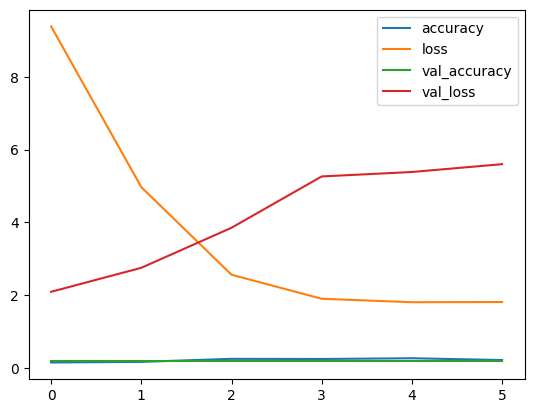

In [54]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [55]:
model.evaluate(X_test,Y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.1542 - loss: 6.0746


[5.600804328918457, 0.20000000298023224]

In [56]:
img = cv2.imread('/content/drive/MyDrive/Deep Learning Projects/CNN-Image Classification/Chess/Queen/00000001.jpg')
img = cv2.resize(img,(128,128),interpolation=cv2.INTER_AREA)
img = (img - img.min())/(img.max() - img.min())

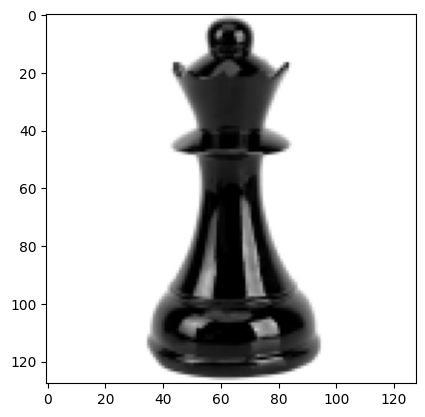

In [57]:
plt.imshow(img)

In [58]:
img.max()

np.float64(1.0)

In [59]:
img.min()

np.float64(0.0)

In [60]:
img = img.reshape([1,128,128,3])

In [61]:
img.shape

(1, 128, 128, 3)

In [62]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step


array([[5.5698285e-05, 9.8251051e-01, 1.2338535e-03, 2.2099041e-06,
        2.6464180e-04, 1.5933026e-02]], dtype=float32)